# 08 · Any EDA in, any engine out

`07_choosing_an_engine` showed one job running on three *engines*. This is the
mirror image — and then the two axes together. **However your geometry is
authored** — programmatically in gdsfactory, in a KLayout/SiEPIC foundry PDK,
or as a plain GDS from any tool — gds_fdtd ingests it, **auto-detects the
ports**, and hands you the same engine-agnostic `Component`. From there the
identical `validate → build → run` drives beamz, tidy3d, or Lumerical.

| Frontend | How you get geometry | Entry point |
|----------|----------------------|-------------|
| **gdsfactory** | parametric Python components (PDK) | `layout.gdsfactory.from_gdsfactory` |
| **KLayout / SiEPIC** | a foundry PDK cell | `lyprocessor.load_cell` → `load_component_from_tech` |
| **raw GDS** | any `.gds` from any tool | `lyprocessor.load_cell` → `load_component_from_tech` |
| **PreFab** | a lithography-predicted GDS | `lyprocessor.load_device(prefab_model=…)` |

The last section is the full **frontend × engine matrix**: three devices — one
from each frontend — each simulated on all three engines, with recorded results
so this notebook reproduces for free.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from gds_fdtd.lyprocessor import load_cell
from gds_fdtd.plotting import plot_component, plot_permittivity
from gds_fdtd.simprocessor import load_component_from_tech
from gds_fdtd.smatrix import SMatrix
from gds_fdtd.spec import SimulationSpec
from gds_fdtd.technology import Technology


def _find(rel: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(rel)


REC = _find("examples/08_frontends/recorded")
tech = Technology.from_yaml(_find("examples/tech.yaml"))
components = {}  # frontend label -> Component

## 1 · gdsfactory — parametric, programmatic

[gdsfactory](https://gdsfactory.github.io/gdsfactory/) builds components in
Python. `from_gdsfactory` reads the polygons on each technology layer and
lifts the gdsfactory ports into gds_fdtd ports. The device: a gentle
**S-bend** (`bend_s`, 5×1 µm), used again in the matrix at the end.

In [2]:
import gdsfactory as gf  # noqa: E402

from gds_fdtd.layout.gdsfactory import from_gdsfactory  # noqa: E402

gf.gpdk.PDK.activate()
gf_bend = from_gdsfactory(gf.components.bend_s(size=(5.0, 1.0)), tech)
gf_bend.name = "gf_bend_s"
components["gdsfactory\nbend_s"] = gf_bend

18:55:04 PDT WARNING: Using canonical configuration directory at                
             '/home/mustafa/.config/tidy3d'. Found legacy directory at          
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

## 2 · KLayout / SiEPIC — a foundry PDK

The same reader consumes a cell straight from the SiEPIC EBeam PDK (the
`ebeam_y_1550` y-branch) — KLayout pin + DevRec conventions become ports and
bounds automatically. This is the path most silicon-photonics tapeouts use,
and it feeds *every* engine (beamz reads the extruded polygons through a
component shim).

In [3]:
try:
    import siepic_ebeam_pdk as pdk

    gds = os.path.join(os.path.dirname(pdk.__file__), "gds", "EBeam", "ebeam_y_1550.gds")
    cell, _ = load_cell(gds, top_cell="ebeam_y_1550")
    ybranch = load_component_from_tech(cell=cell, tech=tech)
    ybranch.name = "ebeam_y_1550"
    components["SiEPIC\nebeam_y_1550"] = ybranch
except ImportError:
    print("(install siepic_ebeam_pdk to load the SiEPIC PDK cell)")

SiEPIC-EBeam-PDK Python module: siepic_ebeam_pdk, KLayout technology: EBeam
KLayout SiEPIC-Tools version 0.5.31


SiEPIC-Tools is up to date (0.5.31 vs 0.5.31).
Version check, time: 0.28484654426574707 seconds
SiEPIC-EBeam-PDK Python module: pymacros, v0.4.53
Libraries associated with Technology EBeam: ['EBeam', 'EBeam-ANT', 'EBeam-Dream', 'EBeam-SiN', 'EBeam_Beta']


## 3 · A raw GDS file — from any tool

No PDK, no framework: point `load_cell` at any `.gds` whose polygons land on
the technology's device/pin/DevRec layers. Here it is `sbend_dontfabme` from
`examples/devices.gds`, the *sharp* S-bend that `06_convergence_and_caching`
uses as its stress test.

In [4]:
cell, _ = load_cell(str(_find("examples/devices.gds")), top_cell="sbend_dontfabme")
sbend = load_component_from_tech(cell=cell, tech=tech)
sbend.name = "sbend_dontfabme"
components["raw GDS\nsbend_dontfabme"] = sbend

## 4 · PreFab — lithography-aware geometry

[PreFab](https://www.prefabphotonics.com/) predicts how a nanofabrication
process will *actually* print your design (corner rounding, proximity
effects). `load_device` runs the model and writes a `<cell>_predicted.gds`,
which then flows through the identical path as any raw GDS. It needs a PreFab
account + network, so it's a recipe here:

```python
from gds_fdtd.lyprocessor import load_device
predicted = load_device(
    "my_design.gds", tech=tech, top_cell="my_cell",
    prefab_model="ANT_NanoSOI_ANF1_d10", output_dir="out/",
)
```

## 5 · One `Component`, whatever the source

Each frontend produced the same kind of object — device polygons,
auto-detected ports, bounds. First the standard geometry views:

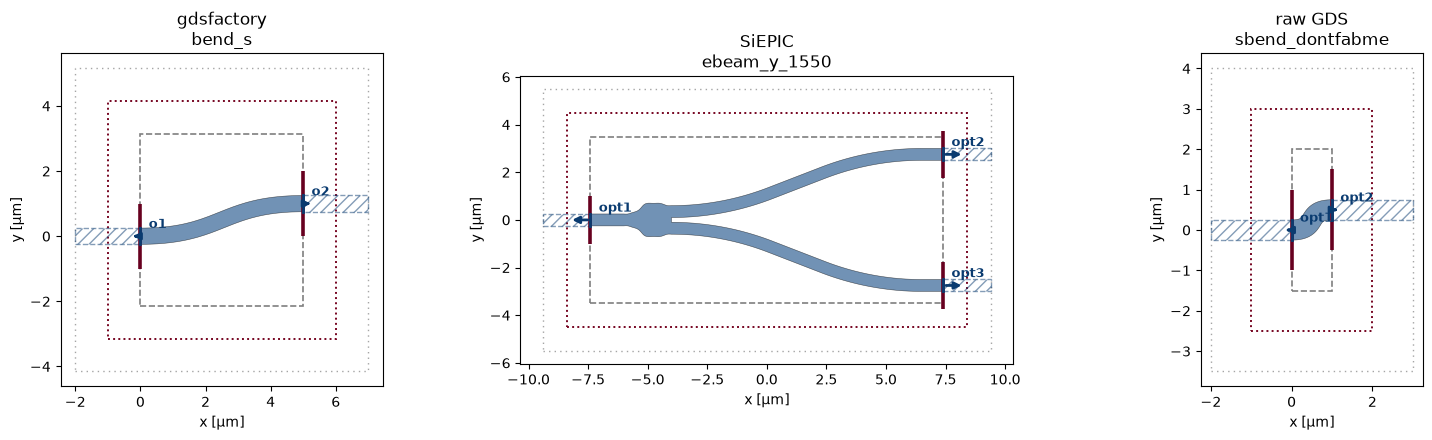

gdsfactory bend_s         : 2 ports ['o1', 'o2']
SiEPIC ebeam_y_1550       : 3 ports ['opt1', 'opt2', 'opt3']
raw GDS sbend_dontfabme   : 2 ports ['opt2', 'opt1']


In [5]:
n = len(components)
fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 4.5))
axes = np.atleast_1d(axes)
for ax, (name, comp) in zip(axes, components.items(), strict=True):
    plot_component(comp, spec=SimulationSpec(), ax=ax)
    ax.set_title(name)
    ax.legend().set_visible(False)
fig.tight_layout()
plt.show()

for name, comp in components.items():
    print(
        f"{name.replace(chr(10), ' '):26s}: {len(comp.ports)} ports {[p.name for p in comp.ports]}"
    )

…and, more stringently, **what the solvers actually mesh**: the rasterized
refractive-index map of each device at the Si core mid-plane. Same reader, same
extrusion, same materials — regardless of which tool drew the polygons.

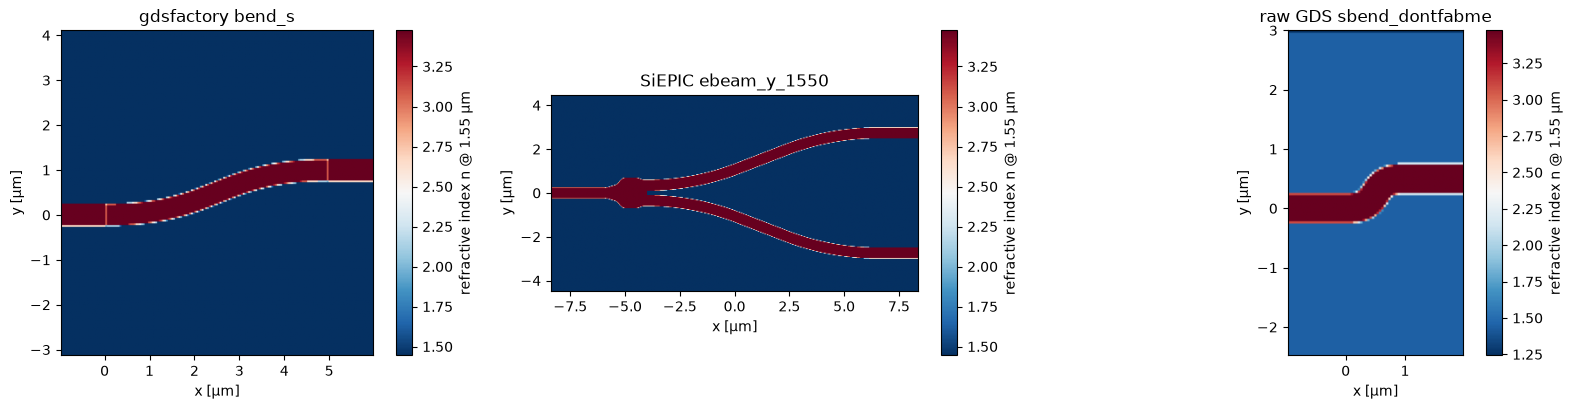

In [6]:
fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 4.2))
axes = np.atleast_1d(axes)
for ax, (name, comp) in zip(axes, components.items(), strict=True):
    plot_permittivity(comp, dx=0.04, axis="z", position=0.11, ax=ax)
    ax.set_title(name.replace(chr(10), " "))
fig.tight_layout()
plt.show()

## 6 · The frontend × engine matrix

Now both axes at once. Three devices — **one from each frontend** — each run
on **all three engines** with the identical `(component, technology, spec)`:

| device | frontend | engines | results |
|--------|----------|---------|---------|
| `gf_bend_s` (gentle S-bend) | gdsfactory | beamz · tidy3d · Lumerical | `recorded/` here (mesh 6, 5 λ) |
| `ebeam_y_1550` (1×2 splitter) | SiEPIC PDK | beamz · tidy3d · Lumerical | `07_choosing_an_engine/recorded/` |
| `sbend_dontfabme` (sharp S-bend) | raw GDS | beamz · tidy3d · Lumerical | `06_convergence_and_caching/recorded/` |

The recorded artifacts are each engine's real output (beamz on this CPU,
tidy3d on the cloud, Lumerical on a licensed workstation).

In [7]:
ENGINES = ("beamz", "tidy3d", "lumerical")

# gdsfactory bend: three full SMatrices recorded next to this notebook
bend_sm = {e: SMatrix.from_npz(str(REC / f"gf_bend_s_{e}.npz")) for e in ENGINES}
# SiEPIC y-branch: three full SMatrices recorded for 07
yb_dir = _find("examples/07_choosing_an_engine/recorded")
yb_sm = {e: SMatrix.from_npz(str(yb_dir / f"ybranch_{e}.npz")) for e in ENGINES}
# raw-GDS sharp sbend: single-wavelength convergence records from 06 (finest mesh each)
sb_dir = _find("examples/06_convergence_and_caching/recorded")
sb = {}
for e in ENGINES:
    mesh_map = json.loads((sb_dir / f"sbend_{e}_convergence.json").read_text())["mesh"]
    finest = str(max(int(k) for k in mesh_map))
    sb[e] = mesh_map[finest]["s21_db"]


def s21_at(sm: SMatrix, wl: float = 1.55) -> float:
    i = int(np.argmin(np.abs(sm.wavelength_um - wl)))
    return float(sm.magnitude_db(out=2, in_=1)[i])


matrix = {
    "gf_bend_s (gdsfactory)": {e: s21_at(bend_sm[e]) for e in ENGINES},
    "ebeam_y_1550 (SiEPIC)": {e: s21_at(yb_sm[e]) for e in ENGINES},
    "sbend_dontfabme (raw GDS)": {e: float(sb[e]) for e in ENGINES},
}
print(f"{'S21 @ 1.55 µm [dB]':28s}" + "".join(f"{e:>12s}" for e in ENGINES) + f"{'worst |Δ|':>12s}")
for dev, row in matrix.items():
    vals = list(row.values())
    spread = max(vals) - min(vals)
    print(f"{dev:28s}" + "".join(f"{v:>12.2f}" for v in vals) + f"{spread:>12.2f}")

S21 @ 1.55 µm [dB]                 beamz      tidy3d   lumerical   worst |Δ|
gf_bend_s (gdsfactory)             -0.31       -0.05       -0.01        0.30
ebeam_y_1550 (SiEPIC)              -3.18       -3.20       -3.20        0.03
sbend_dontfabme (raw GDS)          -1.99       -5.64       -5.63        3.65


The same table as a picture — each cell is one engine's S21 for one device,
colored by how far it sits from that device's median (so a perfectly agreeing
row is uniformly pale):

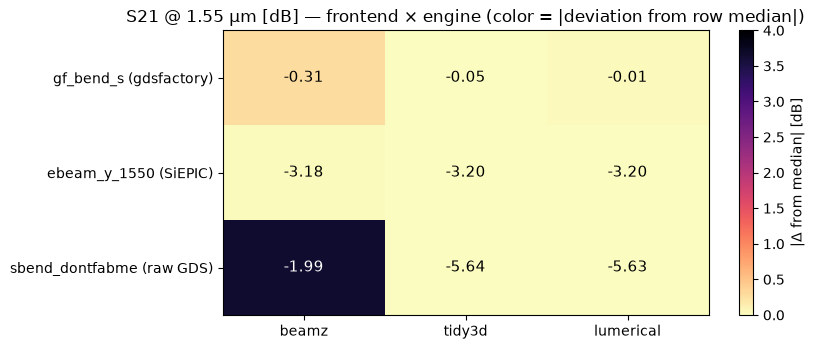

In [8]:
devs = list(matrix)
vals = np.array([[matrix[d][e] for e in ENGINES] for d in devs])
dev_from_median = vals - np.median(vals, axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8.5, 3.6))
im = ax.imshow(np.abs(dev_from_median), cmap="magma_r", vmin=0, vmax=4, aspect="auto")
for i in range(len(devs)):
    for j in range(len(ENGINES)):
        ax.text(
            j,
            i,
            f"{vals[i, j]:.2f}",
            ha="center",
            va="center",
            color="k" if abs(dev_from_median[i, j]) < 2 else "w",
            fontsize=11,
        )
ax.set_xticks(range(len(ENGINES)), ENGINES)
ax.set_yticks(range(len(devs)), devs)
ax.set_title("S21 @ 1.55 µm [dB] — frontend × engine (color = |deviation from row median|)")
fig.colorbar(im, ax=ax, label="|Δ from median| [dB]")
fig.tight_layout()
plt.show()

Reading the matrix:

- **`gf_bend_s`** (gentle, adiabatic): all three engines agree — beamz is
  trustworthy on gradual structures, whatever frontend supplied them.
- **`ebeam_y_1550`** (SiEPIC): all three agree on the −3 dB split to ~0.16 dB
  (see `07` for the full analysis and beamz's reverse-column caveat).
- **`sbend_dontfabme`** (sharp): tidy3d and Lumerical agree to ~0.03 dB while
  beamz sits ~3.6 dB off *and never converges* — the `06_convergence_and_caching`
  lesson, visible here as the one dark cell.

The takeaway: agreement (or disagreement) is a property of the **physics and
the engine**, not of which EDA tool drew the layout.

### The gdsfactory row in full — spectra on all three engines

The matrix shows one number; here is the whole band for the gdsfactory
S-bend: through-port S21 (top) and reflection S11 (bottom) from each engine.

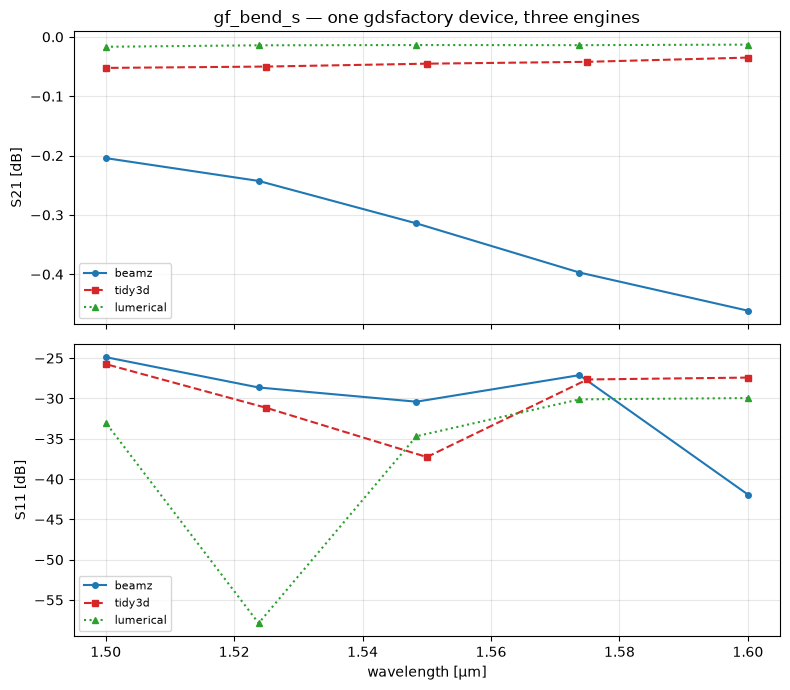

gf_bend_s S21 @1.55: beamz -0.31 dB  tidy3d -0.05 dB  lumerical -0.01 dB
three-engine spread: 0.30 dB on a gdsfactory-authored device


In [9]:
fig, (axT, axR) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
colors = {"beamz": "tab:blue", "tidy3d": "tab:red", "lumerical": "tab:green"}
marks = {"beamz": "o-", "tidy3d": "s--", "lumerical": "^:"}
for e in ENGINES:
    sm = bend_sm[e]
    axT.plot(
        sm.wavelength_um, sm.magnitude_db(out=2, in_=1), marks[e], color=colors[e], ms=4, label=e
    )
    axR.plot(
        sm.wavelength_um, sm.magnitude_db(out=1, in_=1), marks[e], color=colors[e], ms=4, label=e
    )
axT.set_ylabel("S21 [dB]")
axR.set_ylabel("S11 [dB]")
axR.set_xlabel("wavelength [µm]")
axT.set_title("gf_bend_s — one gdsfactory device, three engines")
for a in (axT, axR):
    a.grid(alpha=0.3)
    a.legend(fontsize=8)
fig.tight_layout()
plt.show()

s21s = {e: s21_at(bend_sm[e]) for e in ENGINES}
worst = max(s21s.values()) - min(s21s.values())
print("gf_bend_s S21 @1.55: " + "  ".join(f"{e} {v:+.2f} dB" for e, v in s21s.items()))
print(f"three-engine spread: {worst:.2f} dB on a gdsfactory-authored device")

…and the same run as **fields**: |E|² through the bend from each engine, every
panel on its own true grid coordinates (beamz uniform; tidy3d adaptive;
Lumerical graded). One gdsfactory device, three engines, one guided field.

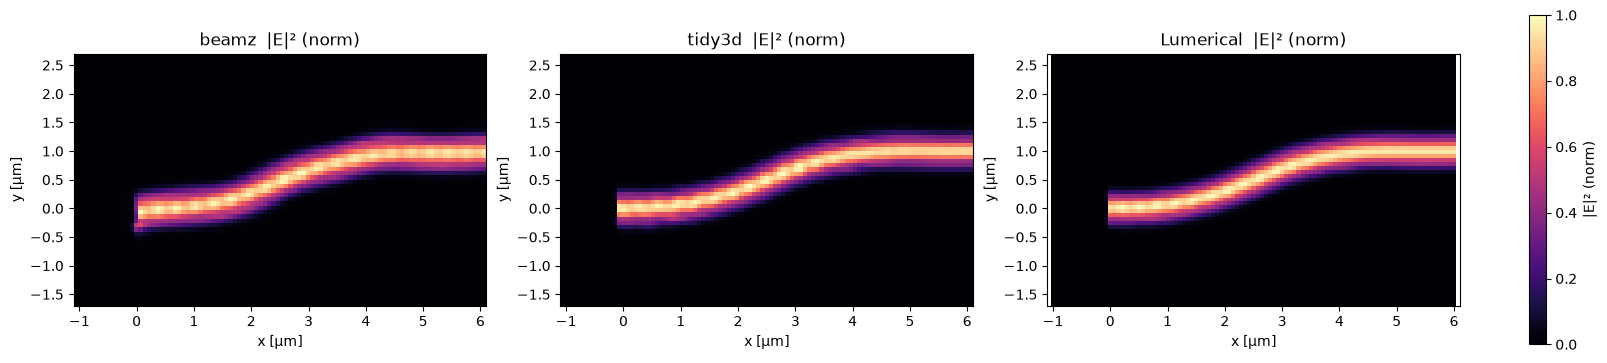

In [10]:
b = np.load(REC / "gf_bend_s_field_beamz.npz")
t = np.load(REC / "gf_bend_s_field_tidy3d.npz")
lu = np.load(REC / "gf_bend_s_field_lumerical.npz")
cx, cy = gf_bend.bounds.x_center, gf_bend.bounds.y_center
bw, bh = float(b["width_um"]), float(b["height_um"])
field_panels = [
    (
        "beamz",
        np.linspace(cx - bw / 2, cx + bw / 2, b["E2"].shape[1]),
        np.linspace(cy - bh / 2, cy + bh / 2, b["E2"].shape[0]),
        b["E2"],
    ),
    ("tidy3d", t["x"], t["y"], t["E2"].T),
    ("Lumerical", lu["x"], lu["y"], lu["E2"].T),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), constrained_layout=True)
for ax, (name, gx, gy, e2) in zip(axes, field_panels, strict=True):
    im = ax.pcolormesh(gx, gy, e2 / e2.max(), shading="nearest", cmap="magma", vmin=0, vmax=1)
    ax.set_xlim(cx - 3.6, cx + 3.6)
    ax.set_ylim(cy - 2.2, cy + 2.2)
    ax.set_aspect("equal")
    ax.set_title(f"{name}  |E|² (norm)")
    ax.set_xlabel("x [µm]")
    ax.set_ylabel("y [µm]")
fig.colorbar(im, ax=axes, label="|E|² (norm)", shrink=0.8)
plt.show()

## 7 · And any of them builds anywhere — offline

The build path is identical no matter the source; nothing below touches an
engine license or the cloud:

In [11]:
from gds_fdtd.solvers import get_solver  # noqa: E402

for name, comp in components.items():
    solver = get_solver("beamz")(
        comp, technology=tech, spec=SimulationSpec(wavelength_points=3, mesh=5)
    )
    problems = solver.validate()
    print(f"{name.replace(chr(10), ' '):26s} -> validate: {problems or 'OK'}")

gdsfactory bend_s          -> validate: OK
SiEPIC ebeam_y_1550        -> validate: OK
raw GDS sbend_dontfabme    -> validate: OK


## Recap & next

Your EDA choice and your engine choice are **independent axes**: gdsfactory,
SiEPIC/KLayout, raw GDS, and PreFab all become the same `Component`, and that
`Component` runs unchanged on beamz, tidy3d, and Lumerical. Cross-engine
agreement depends on the physics (gentle vs radiative structures) and the
engine's model, not on the drawing tool.

- **`06_convergence_and_caching`** — the sharp-bend row of the matrix, in depth.
- **`07_choosing_an_engine`** — the SiEPIC row, in depth.
- **`10_cookbook`** — reference devices with known-good S-parameters.